# EDA Projeto

Notebook inicial para análise exploratória de dados.

In [137]:
import pandas as pd
import requests
import zipfile
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu


df = pd.read_spss('../data/04832.SAV')

In [23]:
url = "https://apisidra.ibge.gov.br/values/t/4099/n2/all/p/202303"
df_ibge = pd.read_json(url)

df_ibge

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N
0,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Grande Região (Código),Grande Região,Trimestre (Código),Trimestre,Variável (Código),Variável
1,2,Grande Região,2,%,7.7,1,Norte,202303,3º trimestre 2023,4099,"Taxa de desocupação, na semana de referência, ..."
2,2,Grande Região,2,%,3.3,1,Norte,202303,3º trimestre 2023,4103,"Coeficiente de variação - Taxa de desocupação,..."
3,2,Grande Região,2,%,13.4,1,Norte,202303,3º trimestre 2023,4114,Taxa combinada de desocupação e de subocupação...
4,2,Grande Região,2,%,2.8,1,Norte,202303,3º trimestre 2023,4115,Coeficiente de variação - Taxa combinada de de...
5,2,Grande Região,2,%,15.0,1,Norte,202303,3º trimestre 2023,4116,Taxa combinada de desocupação e força de traba...
6,2,Grande Região,2,%,2.4,1,Norte,202303,3º trimestre 2023,4117,Coeficiente de variação - Taxa combinada de de...
7,2,Grande Região,2,%,20.3,1,Norte,202303,3º trimestre 2023,4118,Taxa composta de subutilização da força de tra...
8,2,Grande Região,2,%,2.2,1,Norte,202303,3º trimestre 2023,4119,Coeficiente de variação - Taxa composta de sub...
9,2,Grande Região,2,%,10.9,2,Nordeste,202303,3º trimestre 2023,4099,"Taxa de desocupação, na semana de referência, ..."


In [24]:
df_ibge.columns = df_ibge.iloc[0]
df_ibge = df_ibge.iloc[1:].reset_index(drop=True)

df_ibge.head()

,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Grande Região (Código),Grande Região,Trimestre (Código),Trimestre,Variável (Código),Variável
0,2,Grande Região,2,%,7.7,1,Norte,202303,3º trimestre 2023,4099,"Taxa de desocupação, na semana de referência, ..."
1,2,Grande Região,2,%,3.3,1,Norte,202303,3º trimestre 2023,4103,"Coeficiente de variação - Taxa de desocupação,..."
2,2,Grande Região,2,%,13.4,1,Norte,202303,3º trimestre 2023,4114,Taxa combinada de desocupação e de subocupação...
3,2,Grande Região,2,%,2.8,1,Norte,202303,3º trimestre 2023,4115,Coeficiente de variação - Taxa combinada de de...
4,2,Grande Região,2,%,15.0,1,Norte,202303,3º trimestre 2023,4116,Taxa combinada de desocupação e força de traba...


In [ ]:

# API CKAN do Portal de Dados Abertos do TSE
package_id = "comparecimento-e-abstencao-2022"
api_url = f"https://dadosabertos.tse.jus.br/api/3/action/package_show?id={package_id}"

response = requests.get(api_url)
response.raise_for_status()

metadata = response.json()
metadata["success"]

True

In [26]:
resources = metadata["result"]["resources"]

for i, r in enumerate(resources):
    print(i)
    print("Nome:", r.get("name"))
    print("Formato:", r.get("format"))
    print("URL:", r.get("url"))
    print("-" * 80)

0
Nome: Comparecimento e Abstenção
Formato: CSV
URL: https://cdn.tse.jus.br/estatistica/sead/odsele/perfil_comparecimento_abstencao/perfil_comparecimento_abstencao_2022.zip
--------------------------------------------------------------------------------
1
Nome: Pessoas com deficiência
Formato: CSV
URL: https://cdn.tse.jus.br/estatistica/sead/odsele/perfil_comparecimento_abstencao_eleitor_deficiente/perfil_comparecimento_abstencao_eleitor_deficiente_2022.zip
--------------------------------------------------------------------------------
2
Nome: Transferência temporária de eleitor
Formato: CSV
URL: https://cdn.tse.jus.br/estatistica/sead/odsele/perfil_comparecimento_abstencao_eleitor_tte/perfil_comparecimento_abstencao_eleitor_tte_2022.zip
--------------------------------------------------------------------------------


In [27]:
resource = None

for r in resources:
    nome = r.get("name", "").lower()
    if "comparecimento" in nome and "absten" in nome:
        resource = r
        break

resource_url = resource["url"]

In [28]:
response = requests.get(resource_url)
response.raise_for_status()

zip_file = zipfile.ZipFile(BytesIO(response.content))
zip_file.namelist()

['perfil_comparecimento_abstencao_2022_PA.csv',
 'perfil_comparecimento_abstencao_2022_MG.csv',
 'perfil_comparecimento_abstencao_2022_ES.csv',
 'perfil_comparecimento_abstencao_2022_BA.csv',
 'perfil_comparecimento_abstencao_2022_MA.csv',
 'perfil_comparecimento_abstencao_2022_CE.csv',
 'perfil_comparecimento_abstencao_2022_GO.csv',
 'perfil_comparecimento_abstencao_2022_MS.csv',
 'perfil_comparecimento_abstencao_2022_MT.csv',
 'perfil_comparecimento_abstencao_2022_BRASIL.csv',
 'perfil_comparecimento_abstencao_2022_PB.csv',
 'perfil_comparecimento_abstencao_2022_AC.csv',
 'perfil_comparecimento_abstencao_2022_AL.csv',
 'perfil_comparecimento_abstencao_2022_AM.csv',
 'perfil_comparecimento_abstencao_2022_AP.csv',
 'perfil_comparecimento_abstencao_2022_RJ.csv',
 'perfil_comparecimento_abstencao_2022_RN.csv',
 'perfil_comparecimento_abstencao_2022_RR.csv',
 'perfil_comparecimento_abstencao_2022_RO.csv',
 'perfil_comparecimento_abstencao_2022_RS.csv',
 'perfil_comparecimento_abstencao_20

In [29]:
#    Lista todos os CSVs estaduais dentro do ZIP
arquivos_csv = [
    name for name in zip_file.namelist()
    if name.endswith(".csv")
    and "BRASIL" not in name
]

arquivos_csv

['perfil_comparecimento_abstencao_2022_PA.csv',
 'perfil_comparecimento_abstencao_2022_MG.csv',
 'perfil_comparecimento_abstencao_2022_ES.csv',
 'perfil_comparecimento_abstencao_2022_BA.csv',
 'perfil_comparecimento_abstencao_2022_MA.csv',
 'perfil_comparecimento_abstencao_2022_CE.csv',
 'perfil_comparecimento_abstencao_2022_GO.csv',
 'perfil_comparecimento_abstencao_2022_MS.csv',
 'perfil_comparecimento_abstencao_2022_MT.csv',
 'perfil_comparecimento_abstencao_2022_PB.csv',
 'perfil_comparecimento_abstencao_2022_AC.csv',
 'perfil_comparecimento_abstencao_2022_AL.csv',
 'perfil_comparecimento_abstencao_2022_AM.csv',
 'perfil_comparecimento_abstencao_2022_AP.csv',
 'perfil_comparecimento_abstencao_2022_RJ.csv',
 'perfil_comparecimento_abstencao_2022_RN.csv',
 'perfil_comparecimento_abstencao_2022_RR.csv',
 'perfil_comparecimento_abstencao_2022_RO.csv',
 'perfil_comparecimento_abstencao_2022_RS.csv',
 'perfil_comparecimento_abstencao_2022_SC.csv',
 'perfil_comparecimento_abstencao_2022_S

In [30]:
dfs = []

for arquivo in arquivos_csv:
    df_temp = pd.read_csv(
        zip_file.open(arquivo),
        sep=";",
        encoding="latin1",
        low_memory=False
    )
    
    # Extrai a UF do nome do arquivo
    # Exemplo: perfil_comparecimento_abstencao_2022_PA.csv -> PA
    uf = arquivo.replace(".csv", "").split("_")[-1]
    df_temp["SG_UF"] = uf
    
    dfs.append(df_temp)

df_tse = pd.concat(dfs, ignore_index=True)

df_tse.head()

,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,NR_TURNO,SG_UF,CD_MUNICIPIO,NM_MUNICIPIO,NR_ZONA,CD_GENERO,DS_GENERO,...,QT_COMPARECIMENTO_TTE,QT_ABSTENCAO_TTE,QT_COMPAREC_FACULTATIVO,QT_ABST_FACULTATIVO,QT_COMPAREC_OBRIGATORIO,QT_ABST_OBRIGATORIO,QT_COMPAREC_DEFIC_FACULTATIVO,QT_ABST_DEFIC_FACULTATIVO,QT_COMPAREC_DEFIC_OBRIGATORIO,QT_ABST_DEFIC_OBRIGATORIO
0,29/04/2025,22:31:40,2022,1,PA,4006,GOIANÉSIA DO PARÁ,103,2,MASCULINO,...,0,0,7,4,0,0,0,0,0,0
1,29/04/2025,22:31:40,2022,1,PA,4006,GOIANÉSIA DO PARÁ,103,2,MASCULINO,...,0,0,0,0,45,18,0,0,1,0
2,29/04/2025,22:31:40,2022,1,PA,4006,GOIANÉSIA DO PARÁ,103,2,MASCULINO,...,0,0,0,0,7,2,0,0,0,0
3,29/04/2025,22:31:40,2022,1,PA,4006,GOIANÉSIA DO PARÁ,103,2,MASCULINO,...,0,0,0,0,3,0,0,0,0,0
4,29/04/2025,22:31:40,2022,1,PA,4006,GOIANÉSIA DO PARÁ,103,2,MASCULINO,...,0,0,0,0,17,2,0,0,0,0


In [31]:
mapa_regiao = {
    "AC": "NORTE", "AP": "NORTE", "AM": "NORTE", "PA": "NORTE",
    "RO": "NORTE", "RR": "NORTE", "TO": "NORTE",

    "AL": "NORDESTE", "BA": "NORDESTE", "CE": "NORDESTE",
    "MA": "NORDESTE", "PB": "NORDESTE", "PE": "NORDESTE",
    "PI": "NORDESTE", "RN": "NORDESTE", "SE": "NORDESTE",

    "DF": "CENTRO OESTE", "GO": "CENTRO OESTE",
    "MT": "CENTRO OESTE", "MS": "CENTRO OESTE",

    "ES": "SUDESTE", "MG": "SUDESTE", "RJ": "SUDESTE", "SP": "SUDESTE",

    "PR": "SUL", "RS": "SUL", "SC": "SUL"
}

df_tse["REGIAO"] = df_tse["SG_UF"].map(mapa_regiao)

df_tse[["SG_UF", "REGIAO"]].drop_duplicates().sort_values("SG_UF")

,SG_UF,REGIAO
3848630,AC,NORTE
3880940,AL,NORDESTE
4023630,AM,NORTE
4126502,AP,NORTE
1624534,BA,NORDESTE
2558884,CE,NORDESTE
1483582,ES,SUDESTE
2887628,GO,CENTRO OESTE
2270166,MA,NORDESTE
249806,MG,SUDESTE


In [32]:
df.columns

Index(['SEXO', 'IDADE', 'FX_ID', 'ESCOLARIDADE', 'P1A', 'P1B', 'P1C', 'P2_1',
       'P2_2', 'P2_3', 'P3_1', 'P3_2', 'P3_3', 'P3_4', 'P3_5', 'P3_6', 'P4',
       'RACA', 'RELIGIAO', 'REND1', 'REND2', 'REGIAO', 'COND', 'PORTE',
       'ID_Ipec', 'DATA_ENTREVISTA', 'TIPO_COLETA'],
      dtype='object')

In [34]:
dicionario_variaveis = {
    "SEXO": "Sexo do entrevistado",
    "IDADE": "Idade em anos",
    "FX_ID": "Faixa de idade",
    "ESCOLARIDADE": "Escolaridade",
    "P1A": "Lembra em quem votou para deputado estadual em 2022",
    "P1B": "Lembra em quem votou para deputado federal em 2022",
    "P1C": "Lembra em quem votou para senador em 2022",
    "P2_1": "Prioridade política em 1º lugar",
    "P2_2": "Prioridade política em 2º lugar",
    "P2_3": "Prioridade política em 3º lugar",
    "P3_1": "Medida contra fake news - primeira resposta",
    "P3_2": "Medida contra fake news - segunda resposta",
    "P3_3": "Medida contra fake news - terceira resposta",
    "P3_4": "Medida contra fake news - quarta resposta",
    "P3_5": "Medida contra fake news - quinta resposta",
    "P3_6": "Medida contra fake news - sexta resposta",
    "P4": "Vontade de participar da vida política na cidade",
    "RACA": "Raça/cor",
    "RELIGIAO": "Religião",
    "REND1": "Renda pessoal em salários mínimos",
    "REND2": "Renda familiar em salários mínimos",
    "REGIAO": "Região do Brasil",
    "COND": "Condição do município",
    "PORTE": "Porte do município",
    "DATA_ENTREVISTA": "Data da entrevista",
    "TIPO_COLETA": "Tipo de coleta"
}

pd.DataFrame(
    dicionario_variaveis.items(),
    columns=["Variável", "Descrição"]
)

,Variável,Descrição
0,SEXO,Sexo do entrevistado
1,IDADE,Idade em anos
2,FX_ID,Faixa de idade
3,ESCOLARIDADE,Escolaridade
4,P1A,Lembra em quem votou para deputado estadual em...
5,P1B,Lembra em quem votou para deputado federal em ...
6,P1C,Lembra em quem votou para senador em 2022
7,P2_1,Prioridade política em 1º lugar
8,P2_2,Prioridade política em 2º lugar
9,P2_3,Prioridade política em 3º lugar


In [35]:
df.isna().sum()

SEXO                  0
IDADE                 0
FX_ID                 0
ESCOLARIDADE          0
P1A                   0
P1B                   0
P1C                   0
P2_1                  0
P2_2                117
P2_3                209
P3_1                  0
P3_2               1182
P3_3               1696
P3_4               1912
P3_5               1945
P3_6               1959
P4                    0
RACA                  0
RELIGIAO              0
REND1                 0
REND2                 0
REGIAO                0
COND                  0
PORTE                 0
ID_Ipec               0
DATA_ENTREVISTA       0
TIPO_COLETA           0
dtype: int64

In [38]:
df_tratado = df.copy()

In [39]:
cols_com_99 = ["P1A", "P1B", "P1C", "P2_1", "P2_2", "P2_3", "P3_1", "P4", "REND1", "REND2"]

for col in cols_com_99:
    df_tratado[col] = df_tratado[col].replace(99, np.nan)

In [61]:
df_tratado["lembra_voto_estadual"] = df_tratado["P1A"].eq('Sim')
df_tratado["lembra_voto_federal"] = df_tratado["P1B"].eq('Sim')
df_tratado["lembra_voto_senador"] = df_tratado["P1C"].eq('Sim')

df_tratado["nao_lembra_voto_federal"] = df_tratado["P1B"].eq('Não')

In [85]:
df['P2_1'].value_counts()

P2_1
Melhorar a qualidade da saúde                                                    400
Incentivar a geração de empregos                                                 294
Reduzir as desigualdades sociais                                                 286
Reduzir a violência                                                              250
Combater o preconceito (racismo, homofobia, diferença de classe social, etc.)    233
Melhorar a qualidade da educação                                                 222
Preservar os valores ligados à família                                           103
Aumentar os impostos de grandes fortunas (ou dos mais ricos)                      45
Não sabe/ Não respondeu                                                           44
Ampliar os espaços de participação política da população                          40
Defender a igualdade entre homens e mulheres                                      38
Ampliar o uso de energias renováveis                        

In [71]:
df_tratado["tem_vontade_participar"] = df_tratado["P4"].isin(['Muita vontade', 'Pouca vontade'])
df_tratado["sem_vontade_participar"] = df_tratado["P4"].eq('Nenhuma vontade')

In [86]:
df_tratado["priorizou_desigualdade"] = df_tratado[["P2_1", "P2_2", "P2_3"]].eq('Reduzir as desigualdades sociais').any(axis=1)
df_tratado["priorizou_emprego"] = df_tratado[["P2_1", "P2_2", "P2_3"]].eq('Incentivar a geração de empregos').any(axis=1)
df_tratado["priorizou_saude"] = df_tratado[["P2_1", "P2_2", "P2_3"]].eq('Melhorar a qualidade da saúde').any(axis=1)
df_tratado["priorizou_educacao"] = df_tratado[["P2_1", "P2_2", "P2_3"]].eq('Melhorar a qualidade da educação').any(axis=1)
df_tratado["priorizou_violencia"] = df_tratado[["P2_1", "P2_2", "P2_3"]].eq('Reduzir a violência').any(axis=1)

In [90]:
df_tratado["P3_1"].value_counts()

P3_1
Responsabilizar e punir as empresas de tecnologia/comunicação que não removerem postagens com conteúdos falsos          531
Ampliar a regulamentação, as regras a serem cumpridas pelas plataformas digitais (Facebook, Youtube, WhatsApp, etc.)    443
Responsabilizar e punir os usuários que divulgam ou compartilham postagens com notícias ou conteúdos falsos             433
Não sabe/ Não respondeu                                                                                                 201
Responsabilizar, punir ou caçar políticos que divulgam ou compartilham postagens com notícias ou conteúdos falsos       173
Ampliar a regulamentação para usuários que divulgam fake news, criadas por eles próprios ou por terceiros               146
Ampliar a regulamentação para políticos que divulgam fake news, criadas por eles próprios ou por terceiros               73
Name: count, dtype: int64

In [93]:
cols_fake = ["P3_1", "P3_2", "P3_3", "P3_4", "P3_5", "P3_6"]

df_tratado["fake_regula_plataformas"] = df_tratado[cols_fake].eq('Ampliar a regulamentação, as regras a serem cumpridas pelas plataformas digitais (Facebook, Youtube, WhatsApp, etc.)').any(axis=1)
df_tratado["fake_pune_empresas"] = df_tratado[cols_fake].eq('Responsabilizar e punir as empresas de tecnologia/comunicação que não removerem postagens com conteúdos falsos').any(axis=1)
df_tratado["fake_regula_usuarios"] = df_tratado[cols_fake].eq('Ampliar a regulamentação para usuários que divulgam fake news, criadas por eles próprios ou por terceiros').any(axis=1)
df_tratado["fake_pune_usuarios"] = df_tratado[cols_fake].eq('Responsabilizar e punir os usuários que divulgam ou compartilham postagens com notícias ou conteúdos falsos').any(axis=1)
df_tratado["fake_regula_politicos"] = df_tratado[cols_fake].eq('Ampliar a regulamentação para políticos que divulgam fake news, criadas por eles próprios ou por terceiros').any(axis=1)
df_tratado["fake_pune_politicos"] = df_tratado[cols_fake].eq('Responsabilizar, punir ou caçar políticos que divulgam ou compartilham postagens com notícias ou conteúdos falsos').any(axis=1)

In [46]:
df_tratado["SEXO"].value_counts(normalize=True) * 100

SEXO
FEM    51.7
MAS    48.3
Name: proportion, dtype: float64

In [47]:
df_tratado["REGIAO"].value_counts(normalize=True) * 100

REGIAO
SUDESTE         43.2
NORDESTE        25.6
SUL             15.2
CENTRO OESTE     8.0
NORTE            8.0
Name: proportion, dtype: float64

In [48]:
df_tratado["IDADE"].describe()

count    2000.000000
mean       41.261500
std        15.392257
min        16.000000
25%        28.000000
50%        40.000000
75%        53.000000
max        88.000000
Name: IDADE, dtype: float64

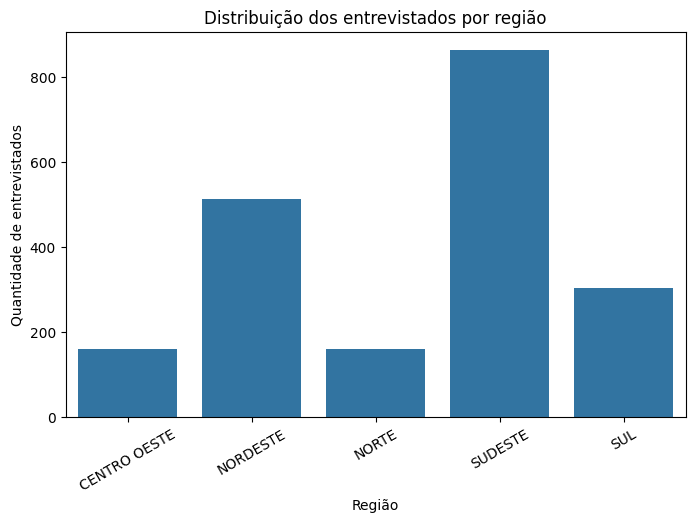

In [55]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_tratado, x="REGIAO")
plt.title("Distribuição dos entrevistados por região")
plt.xlabel("Região")
plt.ylabel("Quantidade de entrevistados")
plt.xticks(rotation=30)
plt.show()

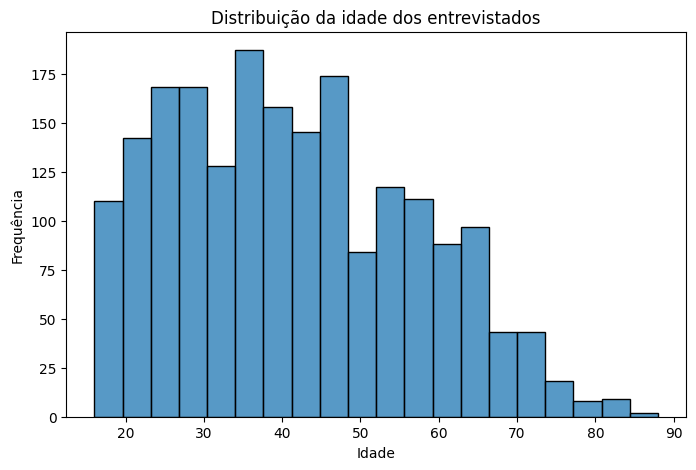

In [56]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_tratado, x="IDADE", bins=20)
plt.title("Distribuição da idade dos entrevistados")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

In [62]:
memoria_voto = df_tratado[
    ["lembra_voto_estadual", "lembra_voto_federal", "lembra_voto_senador"]
].mean().mul(100).reset_index()

memoria_voto.columns = ["Cargo", "Percentual"]

memoria_voto

,Cargo,Percentual
0,lembra_voto_estadual,29.65
1,lembra_voto_federal,29.30
2,lembra_voto_senador,29.40


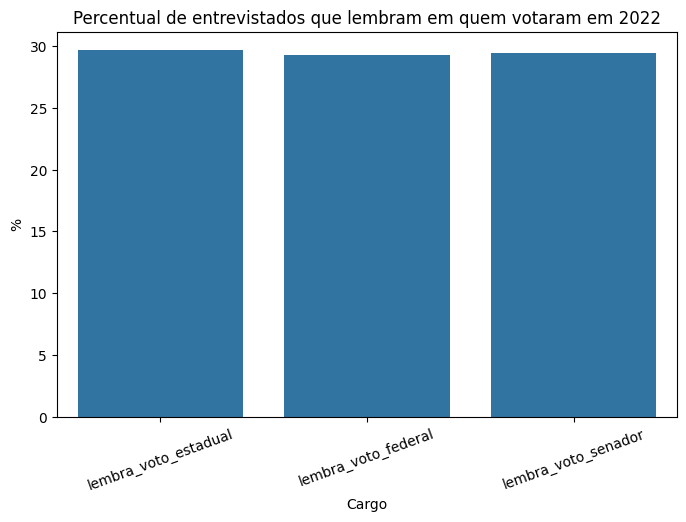

In [63]:
plt.figure(figsize=(8, 5))
sns.barplot(data=memoria_voto, x="Cargo", y="Percentual")
plt.title("Percentual de entrevistados que lembram em quem votaram em 2022")
plt.ylabel("%")
plt.xticks(rotation=20)
plt.show()

In [68]:
df_tratado["P4"].value_counts(normalize=True) * 100

P4
Nenhuma vontade            77.95
Alguma vontade             13.20
Muita vontade               8.45
Não sabe/ Não respondeu     0.40
Name: proportion, dtype: float64

In [72]:
participacao_regiao = (
    df_tratado
    .groupby("REGIAO")["tem_vontade_participar"]
    .mean()
    .mul(100)
    .reset_index()
)

participacao_regiao

C:\Users\User\AppData\Local\Temp\ipykernel_107856\680173117.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("REGIAO")["tem_vontade_participar"]


,REGIAO,tem_vontade_participar
0,CENTRO OESTE,8.125000
1,NORDESTE,9.179688
2,NORTE,7.500000
3,SUDESTE,9.375000
4,SUL,5.263158


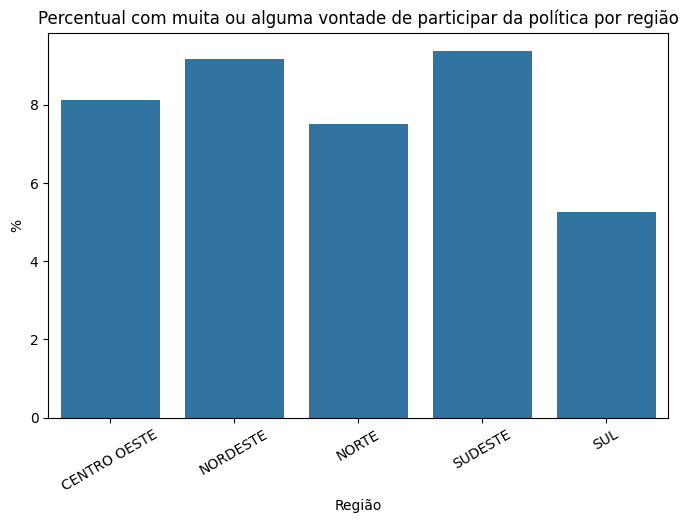

In [74]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=participacao_regiao,
    x="REGIAO",
    y="tem_vontade_participar"
)
plt.title("Percentual com muita ou alguma vontade de participar da política por região")
plt.xlabel("Região")
plt.ylabel("%")
plt.xticks(rotation=30)
plt.show()

In [76]:
cruzamento_voto_participacao = (
    df_tratado
    .groupby("tem_vontade_participar")["lembra_voto_federal"]
    .mean()
    .mul(100)
    .reset_index()
)

cruzamento_voto_participacao

,tem_vontade_participar,lembra_voto_federal
0,False,27.198252
1,True,52.071006


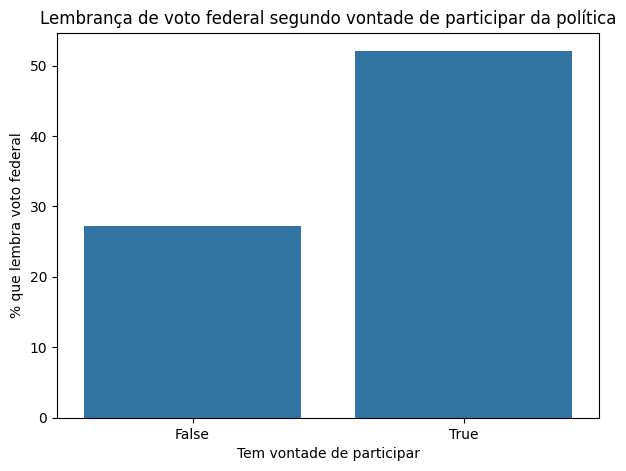

In [77]:
plt.figure(figsize=(7, 5))
sns.barplot(
    data=cruzamento_voto_participacao,
    x="tem_vontade_participar",
    y="lembra_voto_federal"
)
plt.title("Lembrança de voto federal segundo vontade de participar da política")
plt.xlabel("Tem vontade de participar")
plt.ylabel("% que lembra voto federal")
plt.show()

In [87]:
prioridades = df_tratado[
    [
        "priorizou_desigualdade",
        "priorizou_emprego",
        "priorizou_saude",
        "priorizou_educacao",
        "priorizou_violencia"
    ]
].mean().mul(100).sort_values(ascending=False)

prioridades

priorizou_saude           56.65
priorizou_educacao        44.40
priorizou_emprego         41.60
priorizou_violencia       35.00
priorizou_desigualdade    27.80
dtype: float64

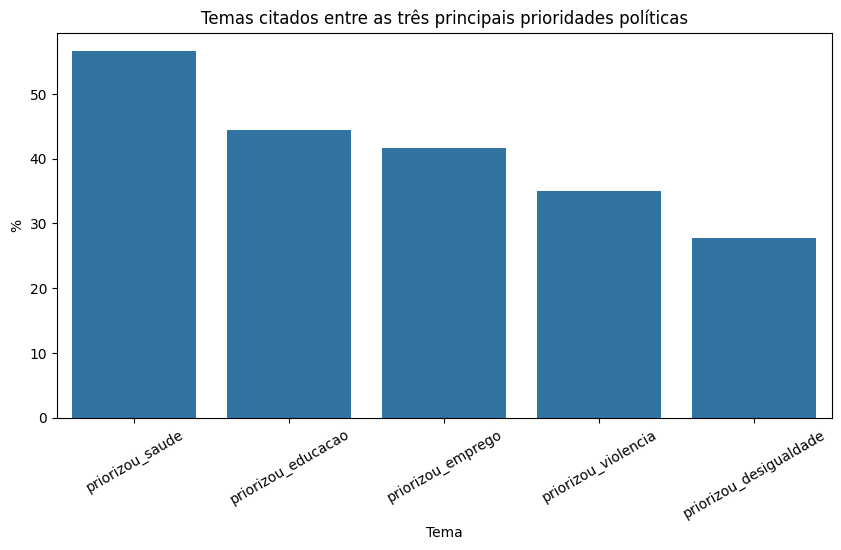

In [88]:
prioridades_df = prioridades.reset_index()
prioridades_df.columns = ["Prioridade", "Percentual"]

plt.figure(figsize=(10, 5))
sns.barplot(data=prioridades_df, x="Prioridade", y="Percentual")
plt.title("Temas citados entre as três principais prioridades políticas")
plt.xlabel("Tema")
plt.ylabel("%")
plt.xticks(rotation=30)
plt.show()

In [94]:
fake_news = df_tratado[
    [
        "fake_regula_plataformas",
        "fake_pune_empresas",
        "fake_regula_usuarios",
        "fake_pune_usuarios",
        "fake_regula_politicos",
        "fake_pune_politicos"
    ]
].mean().mul(100).sort_values(ascending=False)

fake_news

fake_pune_usuarios         41.35
fake_pune_empresas         33.65
fake_pune_politicos        28.85
fake_regula_plataformas    22.15
fake_regula_usuarios       15.65
fake_regula_politicos      13.60
dtype: float64

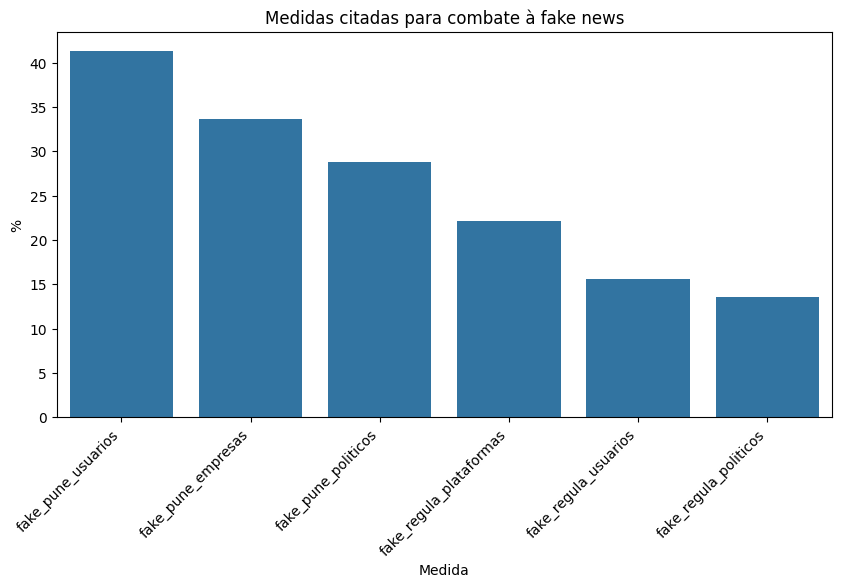

In [95]:
fake_news_df = fake_news.reset_index()
fake_news_df.columns = ["Medida", "Percentual"]

plt.figure(figsize=(10, 5))
sns.barplot(data=fake_news_df, x="Medida", y="Percentual")
plt.title("Medidas citadas para combate à fake news")
plt.xlabel("Medida")
plt.ylabel("%")
plt.xticks(rotation=45, ha="right")
plt.show()

In [127]:
df_tratado['ESCOLARIDADE'].value_counts(normalize=True) * 100

ESCOLARIDADE
3ª série                                     31.20
Superior completo                            14.35
8ª série (ou 9º ano)                         10.35
Superior incompleto                           9.85
4ª série (ou 5º ano)                          8.00
2ª série                                      5.35
1ª série                                      4.30
5ª série (ou 6º ano)                          4.20
Analfabeto                                    2.80
6ª série (ou 7º ano)                          2.40
7ª série (ou 8º ano)                          2.10
2ª série (ou 3º ano)                          1.80
3ª série (ou 4º ano)                          1.65
1ª série (ou 2º ano)                          1.10
Sabe ler/ escrever, mas não cursou escola     0.45
Pré-escola (ou 1º ano)                        0.10
Name: proportion, dtype: float64

In [123]:
tabela = pd.crosstab(
    df_tratado["tem_vontade_participar"],
    df_tratado["lembra_voto_federal"]
)

chi2, p_valor, graus_liberdade, esperado = chi2_contingency(tabela)

print("Estatística qui-quadrado:", chi2)
print("p-valor:", p_valor)
print("Graus de liberdade:", graus_liberdade)

Estatística qui-quadrado: 45.01387904354633
p-valor: 1.956428996228608e-11
Graus de liberdade: 1


In [124]:
tabela_percentual = pd.crosstab(
    df_tratado["tem_vontade_participar"],
    df_tratado["lembra_voto_federal"],
    normalize="index"
) * 100

tabela_percentual.round(2)

lembra_voto_federal,False,True
tem_vontade_participar,,
False,72.80,27.20
True,47.93,52.07


In [125]:
alpha = 0.05

if p_valor < alpha:
    print("Rejeitamos H0.")
    print("Há evidência estatística de associação entre vontade de participar da política e lembrança do voto para deputado federal.")
else:
    print("Não rejeitamos H0.")
    print("Não há evidência estatística suficiente para afirmar associação entre as variáveis.")

Rejeitamos H0.
Há evidência estatística de associação entre vontade de participar da política e lembrança do voto para deputado federal.


In [128]:
def agrupar_escolaridade(valor):
    if valor in [
        "Analfabeto",
        "Sabe ler/ escrever, mas não cursou escola",
        "Pré-escola (ou 1º ano)"
    ]:
        return "Sem escolarização formal"

    elif valor in [
        "1ª série (ou 2º ano)",
        "2ª série (ou 3º ano)",
        "3ª série (ou 4º ano)",
        "4ª série (ou 5º ano)",
        "5ª série (ou 6º ano)",
        "6ª série (ou 7º ano)",
        "7ª série (ou 8º ano)",
        "8ª série (ou 9º ano)"
    ]:
        return "Até ensino fundamental"

    elif valor in [
        "1ª série",
        "2ª série",
        "3ª série"
    ]:
        return "Ensino médio"

    elif valor == "Superior incompleto":
        return "Superior incompleto"

    elif valor == "Superior completo":
        return "Superior completo"

    else:
        return "Não informado"

df_tratado["ESCOLARIDADE_GRUPO"] = df_tratado["ESCOLARIDADE"].apply(agrupar_escolaridade)

In [130]:
df_tratado["ESCOLARIDADE_GRUPO"].value_counts(normalize=True).mul(100).round(2)

ESCOLARIDADE_GRUPO
Ensino médio                40.85
Até ensino fundamental      31.60
Superior completo           14.35
Superior incompleto          9.85
Sem escolarização formal     3.35
Name: proportion, dtype: float64

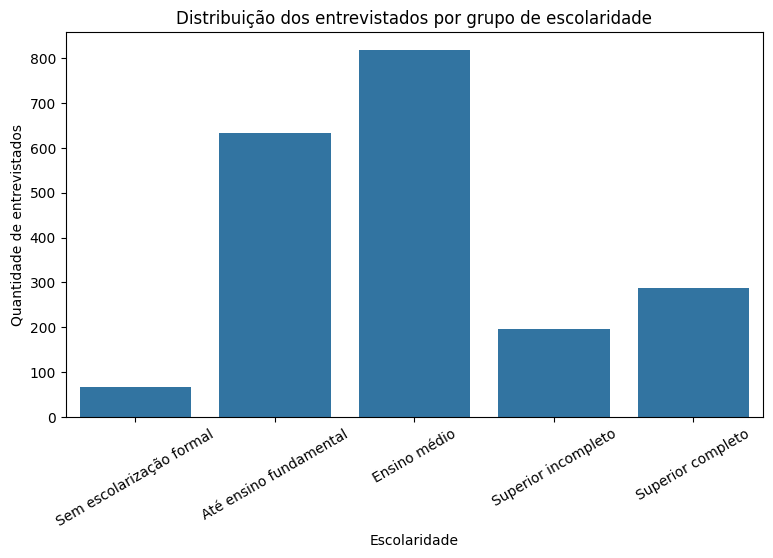

In [131]:
ordem_escolaridade = [
    "Sem escolarização formal",
    "Até ensino fundamental",
    "Ensino médio",
    "Superior incompleto",
    "Superior completo"
]

plt.figure(figsize=(9, 5))
sns.countplot(
    data=df_tratado,
    x="ESCOLARIDADE_GRUPO",
    order=ordem_escolaridade
)

plt.title("Distribuição dos entrevistados por grupo de escolaridade")
plt.xlabel("Escolaridade")
plt.ylabel("Quantidade de entrevistados")
plt.xticks(rotation=30)
plt.show()

In [132]:
participacao_escolaridade = (
    df_tratado
    .groupby("ESCOLARIDADE_GRUPO")["tem_vontade_participar"]
    .mean()
    .mul(100)
    .reindex(ordem_escolaridade)
    .reset_index()
)

participacao_escolaridade

,ESCOLARIDADE_GRUPO,tem_vontade_participar
0,Sem escolarização formal,5.970149
1,Até ensino fundamental,6.962025
2,Ensino médio,8.690330
3,Superior incompleto,8.121827
4,Superior completo,11.846690


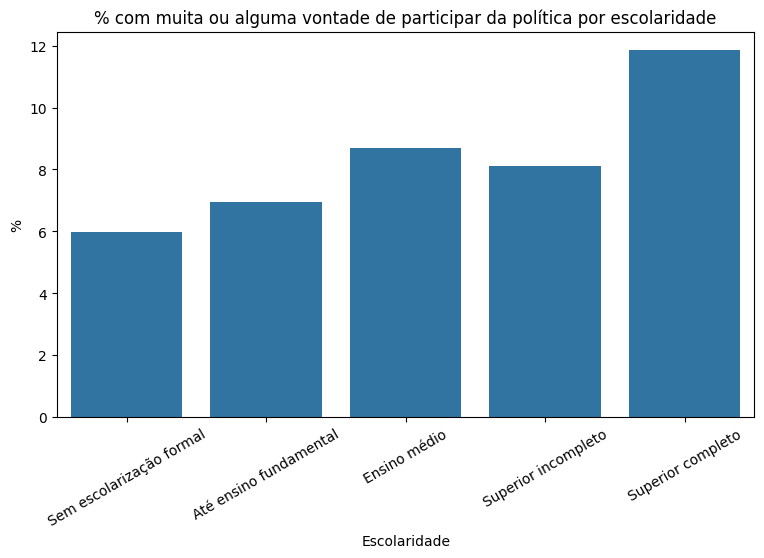

In [133]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=participacao_escolaridade,
    x="ESCOLARIDADE_GRUPO",
    y="tem_vontade_participar",
    order=ordem_escolaridade
)

plt.title("% com muita ou alguma vontade de participar da política por escolaridade")
plt.xlabel("Escolaridade")
plt.ylabel("%")
plt.xticks(rotation=30)
plt.show()

In [135]:
df_teste = df_tratado[
    (df_tratado["ESCOLARIDADE_GRUPO"] != "Não informado") &
    (df_tratado["P4"].isin(["Muita vontade", "Alguma vontade", "Nenhuma vontade"]))
].copy()

tabela = pd.crosstab(
    df_teste["ESCOLARIDADE_GRUPO"],
    df_teste["P4"]
)

display(tabela)

chi2, p_valor, gl, esperado = chi2_contingency(tabela)

print("Qui-quadrado:", chi2)
print("p-valor:", p_valor)
print("Graus de liberdade:", gl)

if p_valor < 0.05:
    print("Rejeitamos H0: há evidência de associação entre escolaridade e vontade de participar da política.")
else:
    print("Não rejeitamos H0: não há evidência suficiente de associação entre escolaridade e vontade de participar da política.")

P4,Alguma vontade,Muita vontade,Nenhuma vontade
ESCOLARIDADE_GRUPO,,,
Até ensino fundamental,56,44,530
Ensino médio,103,71,639
Sem escolarização formal,3,4,59
Superior completo,62,34,190
Superior incompleto,40,16,141


Qui-quadrado: 51.936989294315886
p-valor: 1.730919020250853e-08
Graus de liberdade: 8
Rejeitamos H0: há evidência de associação entre escolaridade e vontade de participar da política.


In [138]:
df_mw = df_tratado.copy()

# Filtra apenas respostas válidas de P4
df_mw = df_mw[
    df_mw["P4"].isin([
        "Muita vontade",
        "Alguma vontade",
        "Nenhuma vontade"
    ])
].copy()

# Cria variável binária de participação
df_mw["grupo_participacao"] = df_mw["P4"].apply(
    lambda x: "Tem vontade de participar" 
    if x in ["Muita vontade", "Alguma vontade"] 
    else "Não tem vontade de participar"
)

# Remove linhas sem idade
df_mw = df_mw.dropna(subset=["IDADE", "grupo_participacao"])

# Separa os dois grupos
idade_com_vontade = df_mw[
    df_mw["grupo_participacao"] == "Tem vontade de participar"
]["IDADE"]

idade_sem_vontade = df_mw[
    df_mw["grupo_participacao"] == "Não tem vontade de participar"
]["IDADE"]

# Aplica Mann-Whitney U
stat, p_valor = mannwhitneyu(
    idade_com_vontade,
    idade_sem_vontade,
    alternative="two-sided"
)

print("Estatística U:", stat)
print("p-valor:", p_valor)

alpha = 0.05

if p_valor < alpha:
    print("Rejeitamos H0.")
    print("Há evidência estatística de diferença na distribuição da idade entre os grupos.")
else:
    print("Não rejeitamos H0.")
    print("Não há evidência estatística suficiente para afirmar diferença na distribuição da idade entre os grupos.")

Estatística U: 349338.5
p-valor: 0.2644019711247433
Não rejeitamos H0.
Não há evidência estatística suficiente para afirmar diferença na distribuição da idade entre os grupos.


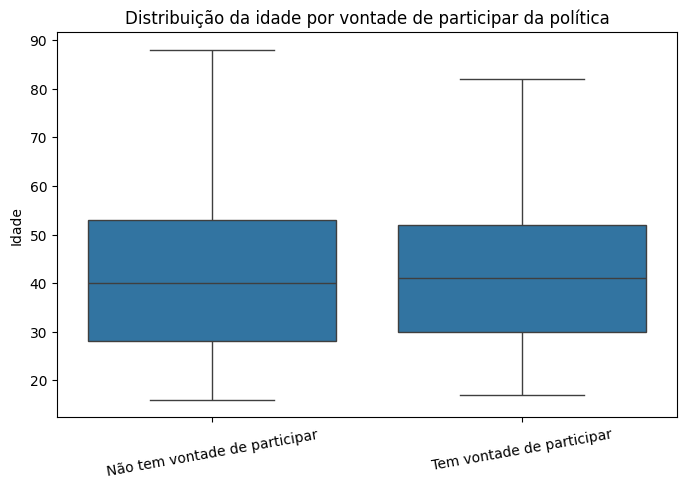

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_mw,
    x="grupo_participacao",
    y="IDADE"
)

plt.title("Distribuição da idade por vontade de participar da política")
plt.xlabel("")
plt.ylabel("Idade")
plt.xticks(rotation=10)
plt.show()

In [101]:
cesop_regiao = (
    df_tratado
    .groupby("REGIAO")
    .agg(
        n_entrevistados=("REGIAO", "size"),
        pct_tem_vontade_participar=("tem_vontade_participar", lambda x: x.mean() * 100),
        pct_sem_vontade_participar=("sem_vontade_participar", lambda x: x.mean() * 100),
        pct_lembra_voto_federal=("lembra_voto_federal", lambda x: x.mean() * 100),
        pct_nao_lembra_voto_federal=("nao_lembra_voto_federal", lambda x: x.mean() * 100),
        pct_priorizou_saude=("priorizou_saude", lambda x: x.mean() * 100),
        pct_priorizou_emprego=("priorizou_emprego", lambda x: x.mean() * 100),
        pct_priorizou_educacao=("priorizou_educacao", lambda x: x.mean() * 100),
        pct_priorizou_violencia=("priorizou_violencia", lambda x: x.mean() * 100),
        pct_fake_pune_politicos=("fake_pune_politicos", lambda x: x.mean() * 100),
        idade_media=("IDADE", "mean")
    )
    .reset_index()
    .rename(columns={"REGIAO_LABEL": "REGIAO"})
)

cesop_regiao

C:\Users\User\AppData\Local\Temp\ipykernel_107856\3839752349.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("REGIAO")


,REGIAO,n_entrevistados,pct_tem_vontade_participar,pct_sem_vontade_participar,pct_lembra_voto_federal,pct_nao_lembra_voto_federal,pct_priorizou_saude,pct_priorizou_emprego,pct_priorizou_educacao,pct_priorizou_violencia,pct_fake_pune_politicos,idade_media
0,CENTRO OESTE,160,8.125000,75.000000,28.125000,68.750000,58.125000,47.500000,41.250000,27.500000,21.250000,40.143750
1,NORDESTE,512,9.179688,79.687500,28.515625,64.843750,54.492188,42.773438,42.578125,40.039062,26.757812,39.966797
2,NORTE,160,7.500000,80.625000,37.500000,60.000000,59.375000,51.875000,47.500000,36.250000,31.250000,38.962500
3,SUDESTE,864,9.375000,76.041667,28.703704,65.509259,55.555556,36.921296,45.023148,34.490741,29.976852,42.295139
4,SUL,304,5.263158,80.592105,28.618421,62.171053,61.184211,44.407895,45.723684,31.250000,31.907895,42.302632


In [106]:
tse_regiao = (
    df_tse
    .groupby("REGIAO", as_index=False)
    .agg(
        qt_aptos=("QT_APTOS", "sum"),
        qt_comparecimento=("QT_COMPARECIMENTO", "sum"),
        qt_abstencao=("QT_ABSTENCAO", "sum")
    )
)

tse_regiao["taxa_comparecimento"] = (
    tse_regiao["qt_comparecimento"] / tse_regiao["qt_aptos"] * 100
)

tse_regiao["taxa_abstencao"] = (
    tse_regiao["qt_abstencao"] / tse_regiao["qt_aptos"] * 100
)

tse_regiao

,REGIAO,qt_aptos,qt_comparecimento,qt_abstencao,taxa_comparecimento,taxa_abstencao
0,CENTRO OESTE,18672556,14585794,4086762,78.113537,21.886463
1,NORDESTE,84781952,68325891,16456061,80.590137,19.409863
2,NORTE,25120820,19612237,5508583,78.071643,21.928357
3,SUDESTE,133414930,104599735,28815195,78.401821,21.598179
4,SUL,45117518,36557623,8559895,81.027558,18.972442


In [107]:
cesop_regiao["REGIAO"].unique()

['CENTRO OESTE', 'NORDESTE', 'NORTE', 'SUDESTE', 'SUL']
Categories (5, object): ['CENTRO OESTE', 'NORDESTE', 'NORTE', 'SUDESTE', 'SUL']

In [108]:
df_final = cesop_regiao.merge(
    tse_regiao,
    on="REGIAO",
    how="left"
)

df_final

,REGIAO,n_entrevistados,pct_tem_vontade_participar,pct_sem_vontade_participar,pct_lembra_voto_federal,pct_nao_lembra_voto_federal,pct_priorizou_saude,pct_priorizou_emprego,pct_priorizou_educacao,pct_priorizou_violencia,pct_fake_pune_politicos,idade_media,qt_aptos,qt_comparecimento,qt_abstencao,taxa_comparecimento,taxa_abstencao
0,CENTRO OESTE,160,8.125000,75.000000,28.125000,68.750000,58.125000,47.500000,41.250000,27.500000,21.250000,40.143750,18672556,14585794,4086762,78.113537,21.886463
1,NORDESTE,512,9.179688,79.687500,28.515625,64.843750,54.492188,42.773438,42.578125,40.039062,26.757812,39.966797,84781952,68325891,16456061,80.590137,19.409863
2,NORTE,160,7.500000,80.625000,37.500000,60.000000,59.375000,51.875000,47.500000,36.250000,31.250000,38.962500,25120820,19612237,5508583,78.071643,21.928357
3,SUDESTE,864,9.375000,76.041667,28.703704,65.509259,55.555556,36.921296,45.023148,34.490741,29.976852,42.295139,133414930,104599735,28815195,78.401821,21.598179
4,SUL,304,5.263158,80.592105,28.618421,62.171053,61.184211,44.407895,45.723684,31.250000,31.907895,42.302632,45117518,36557623,8559895,81.027558,18.972442


In [111]:
df_final[[
    "pct_tem_vontade_participar",
    "pct_sem_vontade_participar",
    "pct_lembra_voto_federal",
    "pct_nao_lembra_voto_federal",
    "taxa_abstencao",
    "taxa_comparecimento"
]].corr()

,pct_tem_vontade_participar,pct_sem_vontade_participar,pct_lembra_voto_federal,pct_nao_lembra_voto_federal,taxa_abstencao,taxa_comparecimento
pct_tem_vontade_participar,1.000000,-0.523622,-0.133661,0.488811,0.418553,-0.418553
pct_sem_vontade_participar,-0.523622,1.000000,0.491663,-0.883781,-0.574081,0.574081
pct_lembra_voto_federal,-0.133661,0.491663,1.000000,-0.741671,0.430368,-0.430368
pct_nao_lembra_voto_federal,0.488811,-0.883781,-0.741671,1.000000,0.211098,-0.211098
taxa_abstencao,0.418553,-0.574081,0.430368,0.211098,1.000000,-1.000000
taxa_comparecimento,-0.418553,0.574081,-0.430368,-0.211098,-1.000000,1.000000


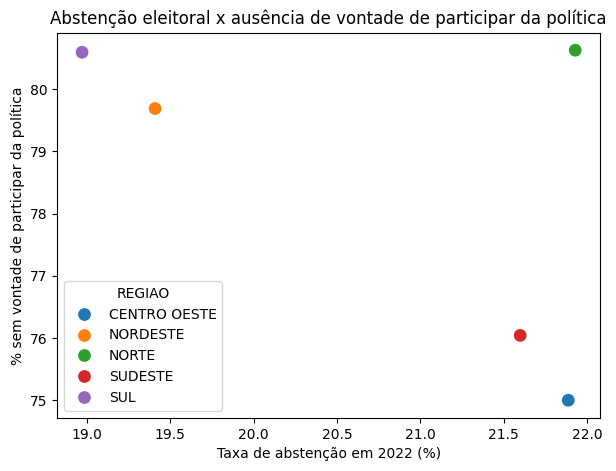

In [112]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df_final,
    x="taxa_abstencao",
    y="pct_sem_vontade_participar",
    hue="REGIAO",
    s=100
)

plt.title("Abstenção eleitoral x ausência de vontade de participar da política")
plt.xlabel("Taxa de abstenção em 2022 (%)")
plt.ylabel("% sem vontade de participar da política")
plt.show()

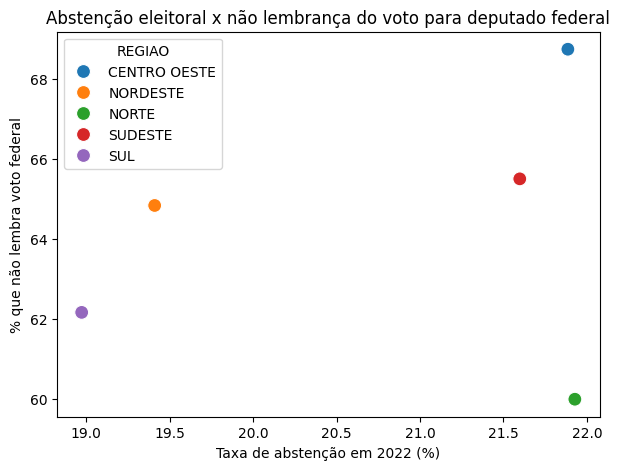

In [113]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df_final,
    x="taxa_abstencao",
    y="pct_nao_lembra_voto_federal",
    hue="REGIAO",
    s=100
)

plt.title("Abstenção eleitoral x não lembrança do voto para deputado federal")
plt.xlabel("Taxa de abstenção em 2022 (%)")
plt.ylabel("% que não lembra voto federal")
plt.show()